# Exploratory Data Analysis Report: US Traffic Dataset (2,000,000 records)

**Dataset:** `cleaned_traffic_data.csv` | **Records:** 2,000,000 | **Features:** 11 | **Analysis:** Comprehensive EDA

---

## 1. Objective of Analysis

This study aims to conduct a rigorous exploratory data analysis (EDA) of a large-scale US traffic dataset comprising two million records. The primary objectives are to:

1. Characterise the distributional properties of key traffic variables including severity, delay, and distance.
2. Investigate the relationship between adverse weather conditions and traffic disruption.
3. Examine congestion patterns across geographical regions and traffic levels.
4. Identify statistically significant associations among continuous and categorical variables to inform predictive modelling and traffic management policy.

## 2. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 3. Load Dataset

In [2]:
df = pd.read_csv(r'D:\ML project\US traffic\data\cleaned_traffic_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (2000000, 11)


,Severity,Distance(mi),DelayFromTypicalTraffic(mins),DelayFromFreeFlowSpeed(mins),Congestion_Speed,City,County,State,Visibility(mi),Weather_Event,Traffic_Level
0,2,1.40,2.58,2.60,Moderate,Dutch Flat,Placer,CA,10.0,Thunderstorm,High
1,0,0.73,0.42,1.00,Slow,Chicago,Cook,IL,10.0,Rain,Medium
2,0,1.80,1.00,2.00,Moderate,Bossier City,Bossier,LA,10.0,Snow,Medium
3,0,1.42,1.00,2.00,Slow,New York,New York,NY,1.0,Thunderstorm,High
4,1,2.60,4.90,6.92,Slow,Long Beach,Los Angeles,CA,9.0,Rain,High


## 4. Dataset Description

In [6]:
print('=== Dataset Overview ===')
print(f'Total Records : {len(df):,}')
print(f'Features      : {df.shape[1]}')
print(f'States Covered: {df["State"].nunique()}')
print(f'Unique Cities : {df["City"].nunique():,}')
print(f'Unique Counties: {df["County"].nunique():,}')
print(f'Missing Values: {df.isnull().sum().sum()}')
print(f'Severity Range: {df["Severity"].min()} – {df["Severity"].max()}')
print()
print('=== Data Types ===')
print(df.dtypes)

=== Dataset Overview ===
Total Records : 2,000,000
Features      : 11
States Covered: 49
Unique Cities : 14,535
Unique Counties: 1,940
Missing Values: 0
Severity Range: 0 – 4

=== Data Types ===
Severity                           int64
Distance(mi)                     float64
DelayFromTypicalTraffic(mins)    float64
DelayFromFreeFlowSpeed(mins)     float64
Congestion_Speed                     str
City                                 str
County                               str
State                                str
Visibility(mi)                   float64
Weather_Event                        str
Traffic_Level                        str
dtype: object


## 5. Data Cleaning & Integrity Checks

In [7]:
# Missing values
print('=== Missing Value Check ===')
print(df.isnull().sum())

# Severity class distribution
print('\n=== Severity Class Counts ===')
sev_counts = df['Severity'].value_counts().sort_index()
for sev, cnt in sev_counts.items():
    print(f'  Severity {sev}: {cnt:>9,}  ({cnt/len(df)*100:.4f}%)')

=== Missing Value Check ===
Severity                         0
Distance(mi)                     0
DelayFromTypicalTraffic(mins)    0
DelayFromFreeFlowSpeed(mins)     0
Congestion_Speed                 0
City                             0
County                           0
State                            0
Visibility(mi)                   0
Weather_Event                    0
Traffic_Level                    0
dtype: int64

=== Severity Class Counts ===
  Severity 0:   484,824  (24.2412%)
  Severity 1:   933,976  (46.6988%)
  Severity 2:   525,011  (26.2506%)
  Severity 3:    56,180  (2.8090%)
  Severity 4:         9  (0.0004%)


In [8]:
# Visibility skewness
vis_skew = df['Visibility(mi)'].skew()
vis_kurt = df['Visibility(mi)'].kurtosis()
print(f'Visibility(mi) Skewness : {vis_skew:.2f}')
print(f'Visibility(mi) Kurtosis : {vis_kurt:.2f}')
print('\nNote: Extreme skewness indicates sensor outliers / data entry anomalies.')
print('Variable retained for completeness but treated with caution.')

Visibility(mi) Skewness : 1414.05
Visibility(mi) Kurtosis : 1999691.90

Note: Extreme skewness indicates sensor outliers / data entry anomalies.
Variable retained for completeness but treated with caution.


## 6. Statistical Analysis

### 6.1 Descriptive Statistics — Numerical Variables

In [16]:
num_cols = ['Severity', 'Distance(mi)', 'DelayFromTypicalTraffic(mins)', 'DelayFromFreeFlowSpeed(mins)','Visibility(mi)']

desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurtosis()
desc.rename(columns={'50%': 'median', '25%': 'Q1', '75%': 'Q3'})

,count,mean,std,min,Q1,median,Q3,max,skewness,kurtosis
Severity,2000000.0,1.076287,0.781984,0.0,1.00,1.00,2.00,4.000000e+00,0.218626,-5.892953e-01
Distance(mi),2000000.0,2.988470,2.882045,0.0,1.26,2.32,3.78,1.858700e+02,4.592686,6.916695e+01
DelayFromTypicalTraffic(mins),2000000.0,2.814574,4.055315,0.0,0.55,1.92,3.95,2.872500e+02,6.454254,1.195257e+02
DelayFromFreeFlowSpeed(mins),2000000.0,4.018185,4.561847,0.0,1.82,3.00,5.00,2.934000e+02,5.788945,8.810022e+01
Visibility(mi),2000000.0,10.242573,1980.400347,0.0,10.00,10.00,10.00,2.800610e+06,1414.051051,1.999692e+06


### 6.2 Correlation Analysis

In [10]:
corr_cols = ['Severity', 'Distance(mi)', 'DelayFromTypicalTraffic(mins)',
             'DelayFromFreeFlowSpeed(mins)', 'Visibility(mi)']
corr_matrix = df[corr_cols].corr()

print('=== Pearson Correlation Matrix ===')
print(corr_matrix.round(4))

print('\n=== Key Pairs ===')
pairs = [
    ('Severity', 'DelayFromFreeFlowSpeed(mins)'),
    ('Severity', 'DelayFromTypicalTraffic(mins)'),
    ('Severity', 'Distance(mi)'),
    ('Severity', 'Visibility(mi)'),
    ('DelayFromTypicalTraffic(mins)', 'DelayFromFreeFlowSpeed(mins)'),
]
for a, b in pairs:
    r = corr_matrix.loc[a, b]
    print(f'  {a} ↔ {b}: r = {r:.4f}')

=== Pearson Correlation Matrix ===
                               Severity  Distance(mi)  \
Severity                         1.0000        0.3484   
Distance(mi)                     0.3484        1.0000   
DelayFromTypicalTraffic(mins)    0.4252        0.4218   
DelayFromFreeFlowSpeed(mins)     0.4431        0.5587   
Visibility(mi)                  -0.0001       -0.0001   

                               DelayFromTypicalTraffic(mins)  \
Severity                                              0.4252   
Distance(mi)                                          0.4218   
DelayFromTypicalTraffic(mins)                         1.0000   
DelayFromFreeFlowSpeed(mins)                          0.8688   
Visibility(mi)                                       -0.0002   

                               DelayFromFreeFlowSpeed(mins)  Visibility(mi)  
Severity                                             0.4431         -0.0001  
Distance(mi)                                         0.5587         -0.0001  
Del

### 6.3 Group-level Statistics

In [11]:
# Traffic Level vs Delay from Free Flow
tl_stats = (df.groupby('Traffic_Level')['DelayFromFreeFlowSpeed(mins)']
              .agg(['mean', 'std', 'median'])
              .rename(columns={'mean': 'Mean Delay (min)', 'std': 'Std Dev', 'median': 'Median'}))
order = ['Low', 'Medium', 'High']
print('=== Traffic Level — Mean Delay from Free Flow ===')
print(tl_stats.reindex(order).round(3))

=== Traffic Level — Mean Delay from Free Flow ===
               Mean Delay (min)  Std Dev  Median
Traffic_Level                                   
Low                       1.802    1.359    1.98
Medium                    2.737    2.297    2.00
High                      6.987    6.331    5.37


In [12]:
# Weather Event vs Delay from Typical Traffic
we_stats = (df.groupby('Weather_Event')['DelayFromTypicalTraffic(mins)']
              .agg(['mean', 'median', 'max'])
              .rename(columns={'mean': 'Mean Delay (min)', 'median': 'Median', 'max': 'Max'}))
print('=== Weather Event — Delay from Typical Traffic ===')
print(we_stats.round(3))

=== Weather Event — Delay from Typical Traffic ===
               Mean Delay (min)  Median     Max
Weather_Event                                  
Fog                       2.778    1.83  221.00
Rain                      2.783    1.82  180.00
Snow                      2.918    2.00  287.25
Thunderstorm              2.771    1.83  189.00


## 7. Graphical Analysis

### 5.1 Count Plot — Severity Level Distribution

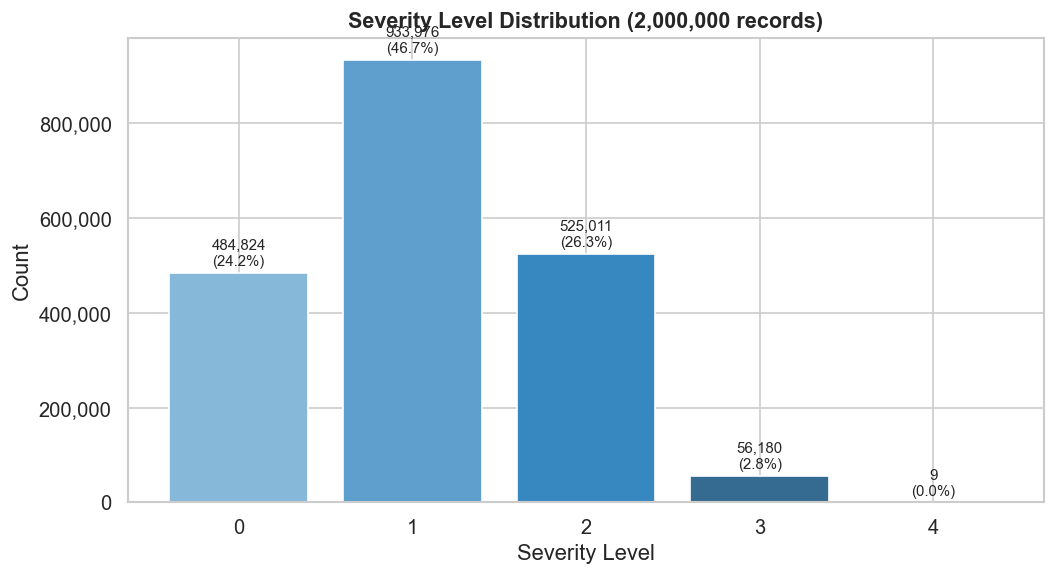

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sev_counts = df['Severity'].value_counts().sort_index()
bars = ax.bar(sev_counts.index.astype(str), sev_counts.values,
              color=sns.color_palette('Blues_d', len(sev_counts)), edgecolor='white')

for bar, (sev, cnt) in zip(bars, sev_counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8000,
            f'{cnt:,}\n({cnt/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

ax.set_title('Severity Level Distribution (2,000,000 records)', fontsize=13, fontweight='bold')
ax.set_xlabel('Severity Level')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### 5.2 Count Plots — Traffic Level and Weather Event

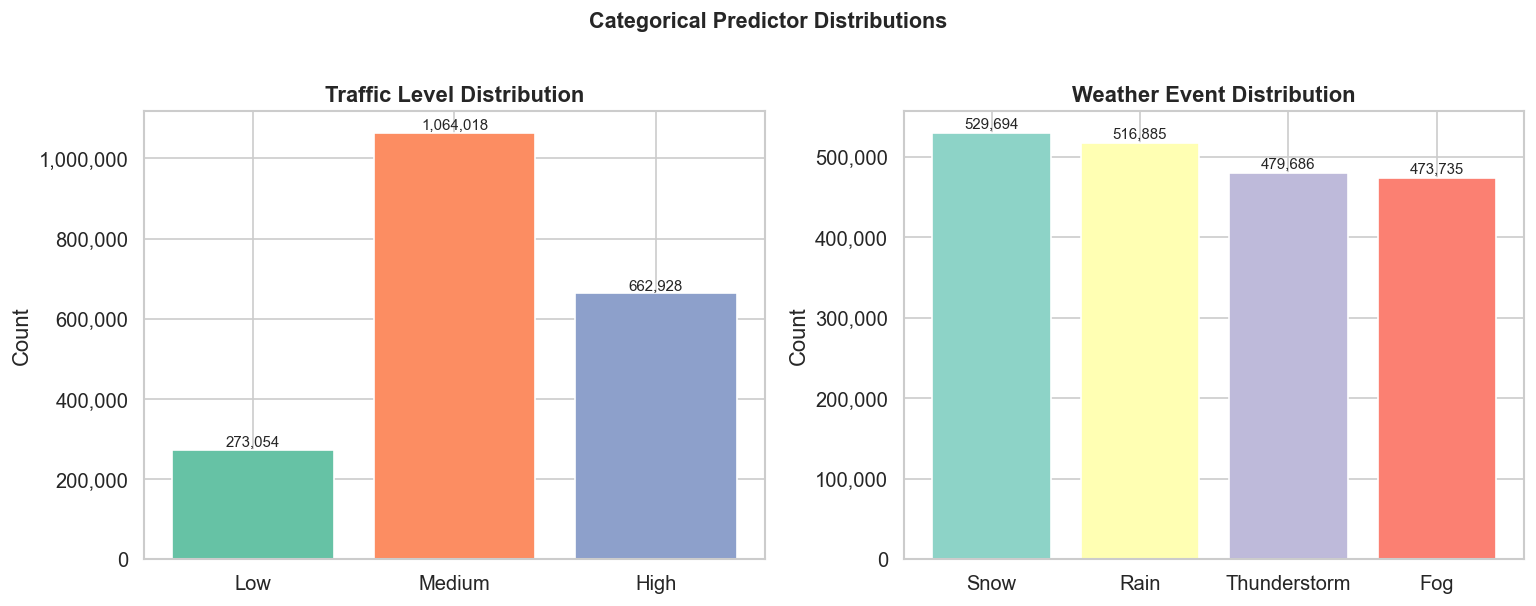

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Traffic Level
tl_order = ['Low', 'Medium', 'High']
tl_counts = df['Traffic_Level'].value_counts().reindex(tl_order)
axes[0].bar(tl_counts.index, tl_counts.values,
            color=sns.color_palette('Set2', 3), edgecolor='white')
for i, (lvl, cnt) in enumerate(tl_counts.items()):
    axes[0].text(i, cnt + 8000, f'{cnt:,}', ha='center', fontsize=9)
axes[0].set_title('Traffic Level Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Weather Event
we_counts = df['Weather_Event'].value_counts()
axes[1].bar(we_counts.index, we_counts.values,
            color=sns.color_palette('Set3', 4), edgecolor='white')
for i, (evt, cnt) in enumerate(we_counts.items()):
    axes[1].text(i, cnt + 5000, f'{cnt:,}', ha='center', fontsize=9)
axes[1].set_title('Weather Event Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Categorical Predictor Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Histogram — Delay from Typical Traffic

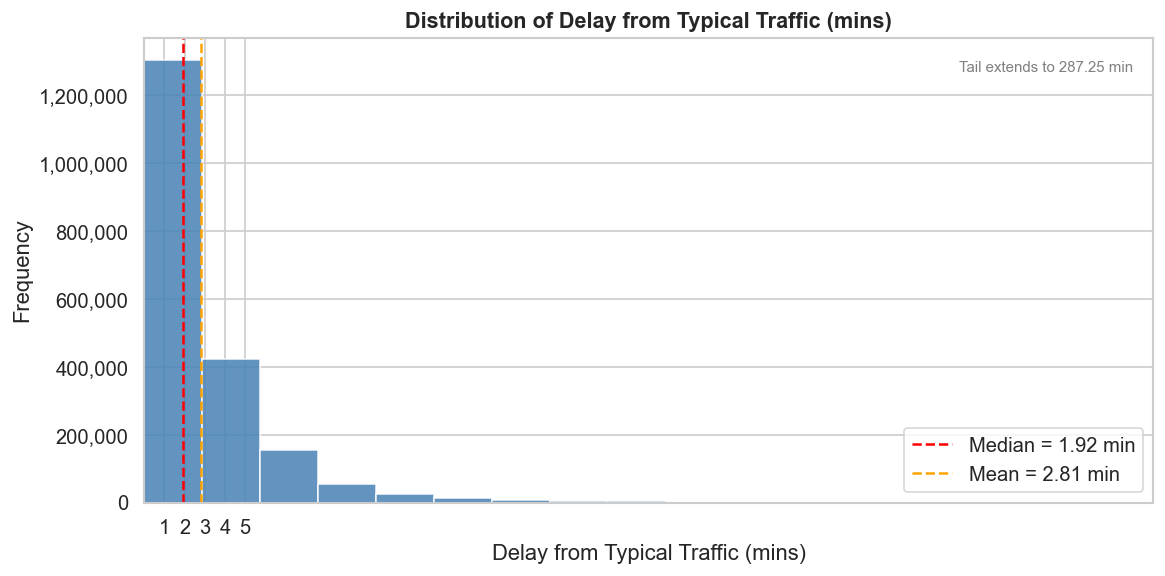

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['DelayFromTypicalTraffic(mins)'], bins=100, color='steelblue',
        edgecolor='white', alpha=0.85)
ax.axvline(df['DelayFromTypicalTraffic(mins)'].median(), color='red',
           linestyle='--', linewidth=1.5, label=f'Median = {df["DelayFromTypicalTraffic(mins)"].median():.2f} min')
ax.axvline(df['DelayFromTypicalTraffic(mins)'].mean(), color='orange',
           linestyle='--', linewidth=1.5, label=f'Mean = {df["DelayFromTypicalTraffic(mins)"].mean():.2f} min')
ax.set_title('Distribution of Delay from Typical Traffic (mins)', fontsize=13, fontweight='bold')
ax.set_xlabel('Delay from Typical Traffic (mins)')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 50)  # focus on bulk; tail extends to 287
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
ax.text(0.98, 0.95, 'Tail extends to 287.25 min', transform=ax.transAxes,
        ha='right', va='top', color='grey', fontsize=9)
plt.tight_layout()
plt.xticks([1,2,3,4,5])
plt.show()

### 5.4 Histogram — Distribution of Distance (mi)

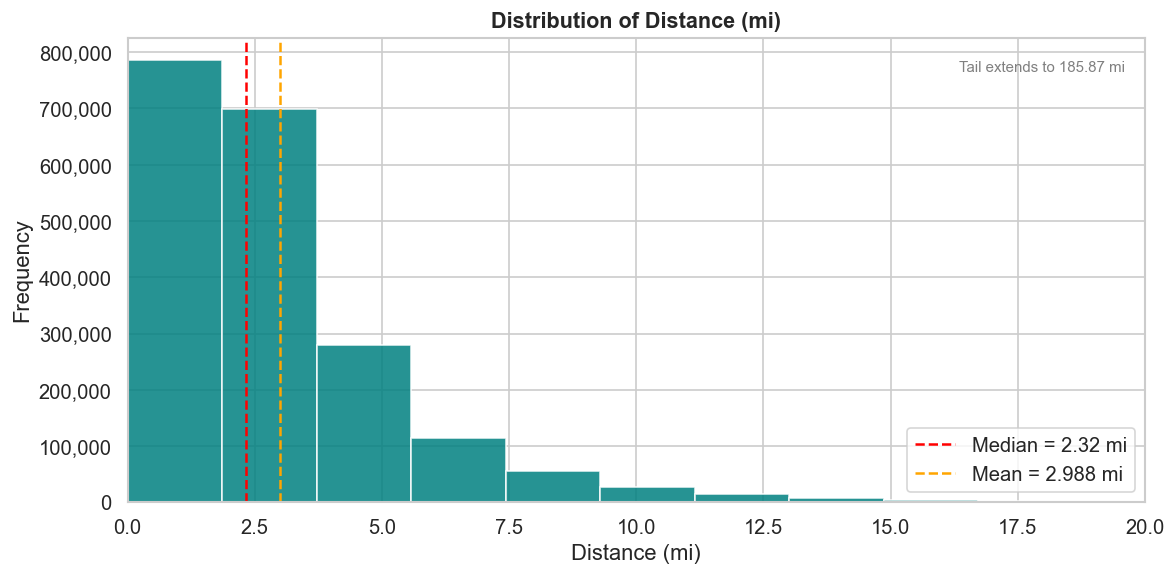

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Distance(mi)'], bins=100, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(df['Distance(mi)'].median(), color='red', linestyle='--', linewidth=1.5,
           label=f'Median = {df["Distance(mi)"].median():.2f} mi')
ax.axvline(df['Distance(mi)'].mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Mean = {df["Distance(mi)"].mean():.3f} mi')
ax.set_title('Distribution of Distance (mi)', fontsize=13, fontweight='bold')
ax.set_xlabel('Distance (mi)')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.text(0.98, 0.95, 'Tail extends to 185.87 mi', transform=ax.transAxes,
        ha='right', va='top', color='grey', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Box Plot — Severity vs. Delay from Free Flow Speed

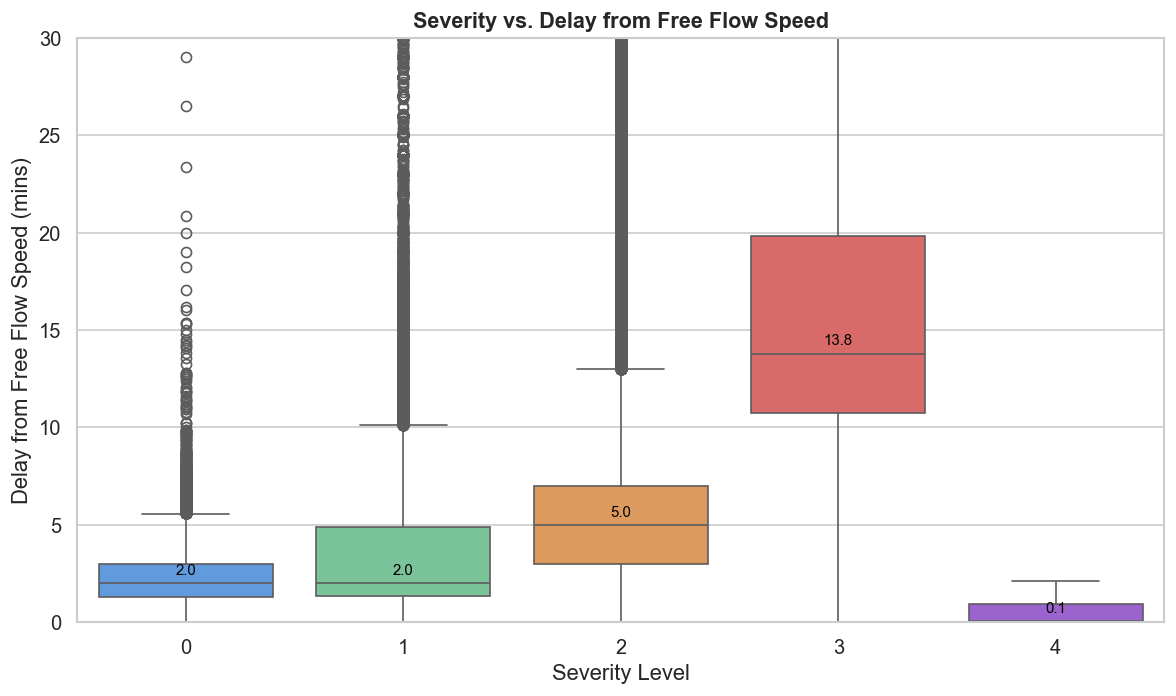

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

palette = {
    '0': '#4e9af1',
    '1': '#6fcf97',
    '2': '#f2994a',
    '3': '#eb5757',
    '4': '#9b51e0'
}

sns.boxplot(
    data=df,
    x='Severity',
    y='DelayFromFreeFlowSpeed(mins)',
    palette=palette,
    ax=ax
)

ax.set_title('Severity vs. Delay from Free Flow Speed', fontsize=13, fontweight='bold')
ax.set_xlabel('Severity Level')
ax.set_ylabel('Delay from Free Flow Speed (mins)')
ax.set_ylim(0, 30)

# Annotate medians
medians = df.groupby('Severity')['DelayFromFreeFlowSpeed(mins)'].median()

for i, sev in enumerate(sorted(medians.index)):
    med = medians.loc[sev]
    ax.text(
        i,
        med + 0.3,
        f'{med:.1f}',
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

plt.tight_layout()
plt.show()

### 5.6 Box Plot — Traffic Level vs. Delay from Free Flow Speed

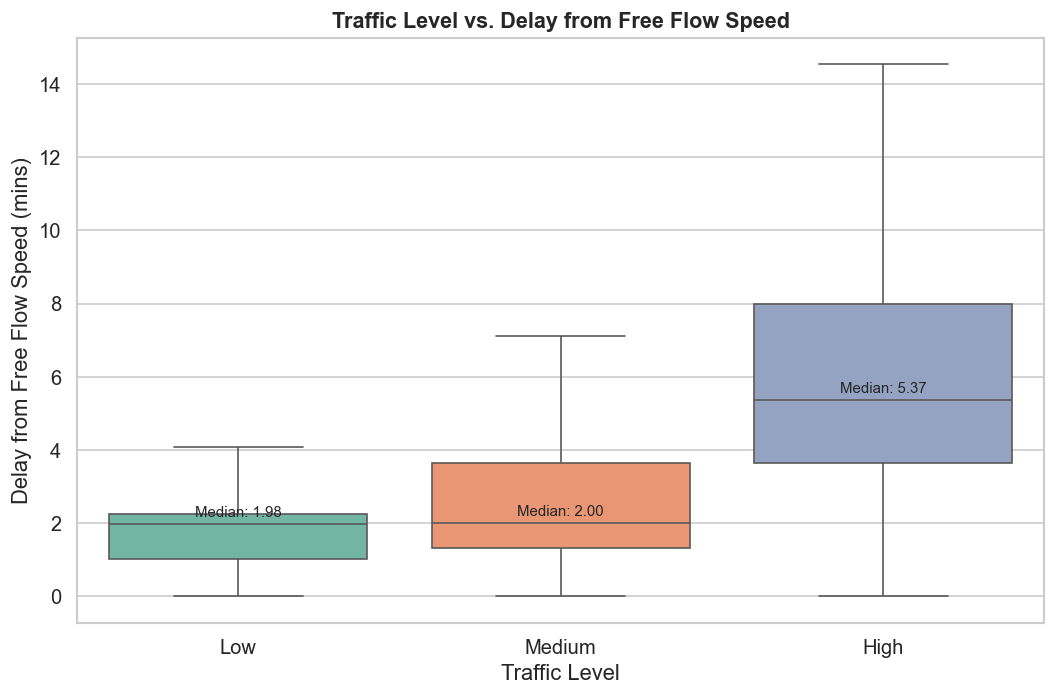

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
tl_order = ['Low', 'Medium', 'High']
sns.boxplot(data=df, x='Traffic_Level', y='DelayFromFreeFlowSpeed(mins)',
            order=tl_order, palette='Set2', showfliers=False, ax=ax)
ax.set_title('Traffic Level vs. Delay from Free Flow Speed', fontsize=13, fontweight='bold')
ax.set_xlabel('Traffic Level')
ax.set_ylabel('Delay from Free Flow Speed (mins)')

medians = df.groupby('Traffic_Level')['DelayFromFreeFlowSpeed(mins)'].median().reindex(tl_order)
for i, (lvl, med) in enumerate(medians.items()):
    ax.text(i, med + 0.2, f'Median: {med:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 5.7 Heatmap — Severity × Traffic Level (Count)

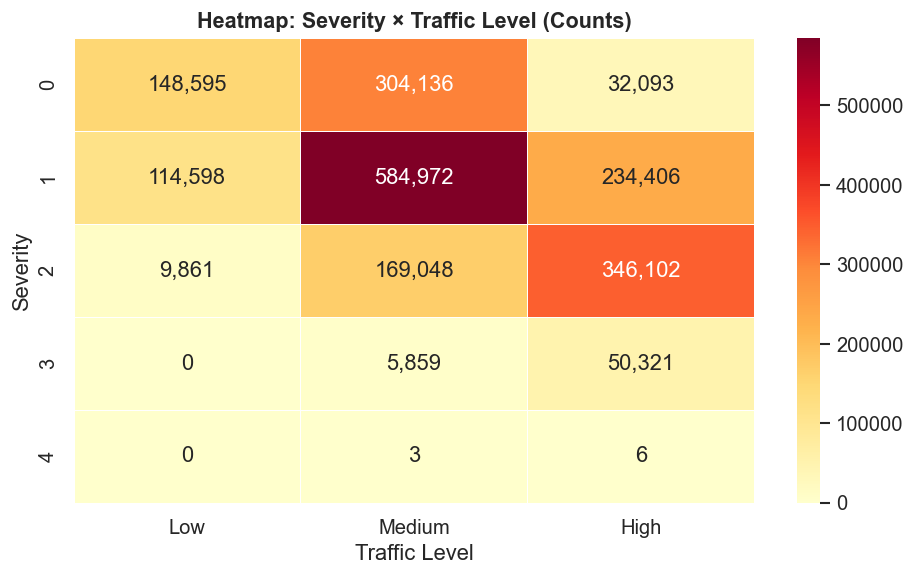

In [19]:
ct = pd.crosstab(df['Severity'], df['Traffic_Level'])[['Low', 'Medium', 'High']]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt=',d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Heatmap: Severity × Traffic Level (Counts)', fontsize=13, fontweight='bold')
ax.set_xlabel('Traffic Level')
ax.set_ylabel('Severity')
plt.tight_layout()
plt.show()

### 5.8 Heatmap — Weather Event × Traffic Level (Count)

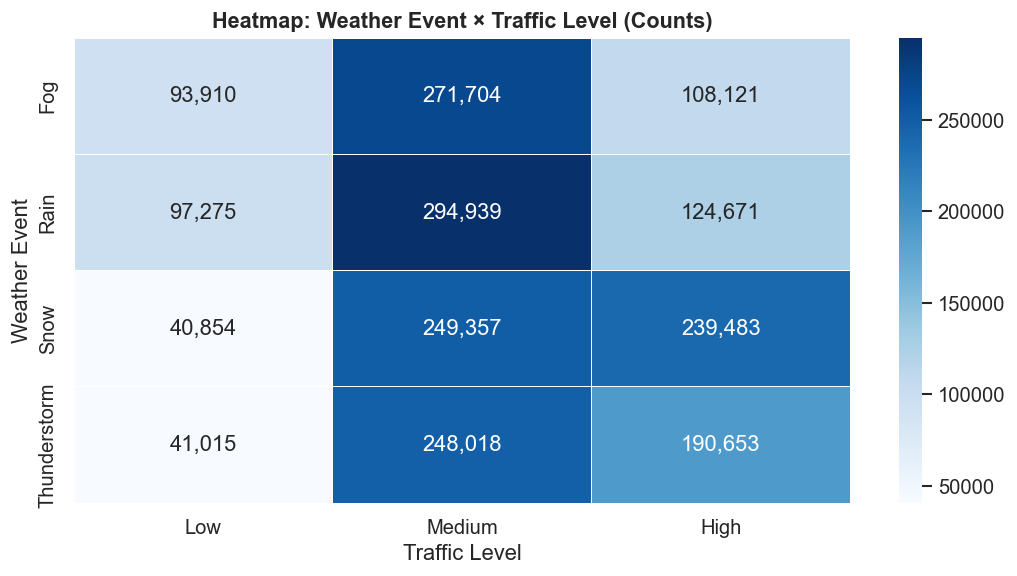

In [20]:
ct2 = pd.crosstab(df['Weather_Event'], df['Traffic_Level'])[['Low', 'Medium', 'High']]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(ct2, annot=True, fmt=',d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Heatmap: Weather Event × Traffic Level (Counts)', fontsize=13, fontweight='bold')
ax.set_xlabel('Traffic Level')
ax.set_ylabel('Weather Event')
plt.tight_layout()
plt.show()

### 5.9 Scatter Plot — Distance vs. Delay (Sampled, coloured by Severity)

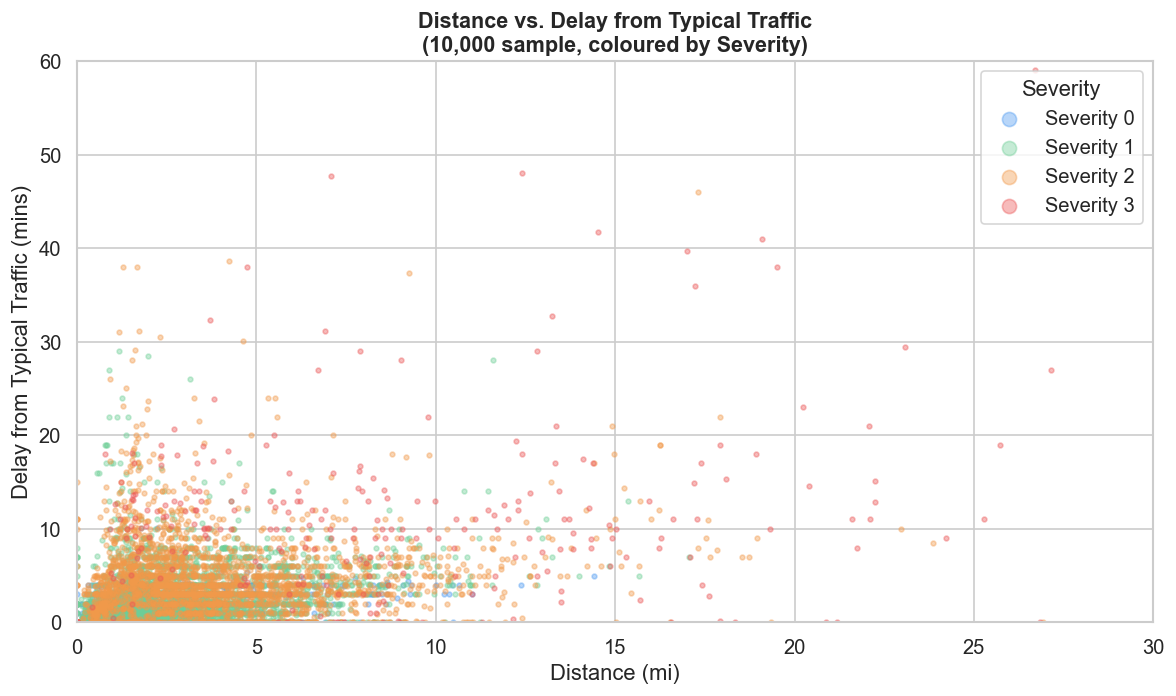

In [21]:
sample = df.sample(10_000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(10, 6))
palette = {0: '#4e9af1', 1: '#6fcf97', 2: '#f2994a', 3: '#eb5757', 4: '#9b51e0'}
for sev in sorted(sample['Severity'].unique()):
    sub = sample[sample['Severity'] == sev]
    ax.scatter(sub['Distance(mi)'], sub['DelayFromTypicalTraffic(mins)'],
               c=palette[sev], label=f'Severity {sev}', alpha=0.4, s=8)

ax.set_title('Distance vs. Delay from Typical Traffic\n(10,000 sample, coloured by Severity)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Distance (mi)')
ax.set_ylabel('Delay from Typical Traffic (mins)')
ax.set_xlim(0, 30)
ax.set_ylim(0, 60)
ax.legend(title='Severity', markerscale=3)
plt.tight_layout()
plt.show()

### 5.10 Distribution Plot — Delay by Congestion Speed

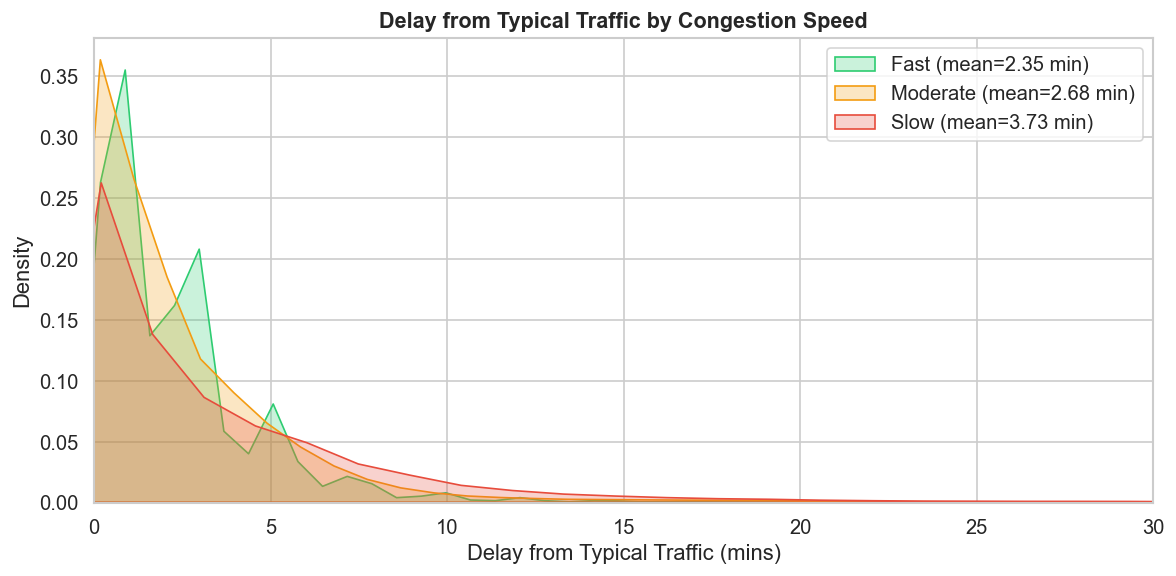

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
palette_cs = {'Fast': '#2ecc71', 'Moderate': '#f39c12', 'Slow': '#e74c3c'}

for speed, color in palette_cs.items():
    subset = df[df['Congestion_Speed'] == speed]['DelayFromTypicalTraffic(mins)']
    mean_val = subset.mean()
    sns.kdeplot(subset, ax=ax, label=f'{speed} (mean={mean_val:.2f} min)', color=color, fill=True, alpha=0.25)

ax.set_title('Delay from Typical Traffic by Congestion Speed', fontsize=13, fontweight='bold')
ax.set_xlabel('Delay from Typical Traffic (mins)')
ax.set_ylabel('Density')
ax.set_xlim(0, 30)
ax.legend()
plt.tight_layout()
plt.show()

### 5.11 Pair Plot — Correlation Heatmap (Numerical Variables)

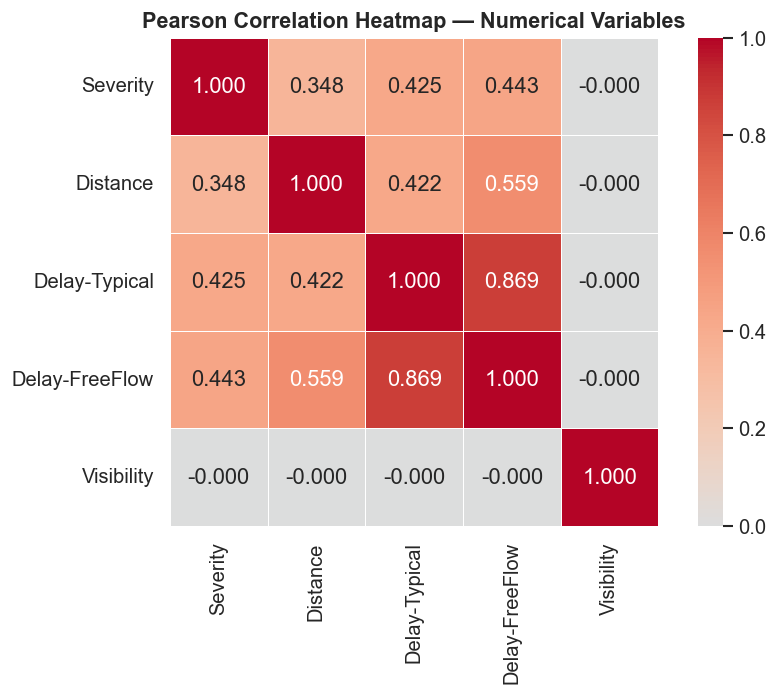

In [14]:
corr_cols = ['Severity', 'Distance(mi)', 'DelayFromTypicalTraffic(mins)',
             'DelayFromFreeFlowSpeed(mins)', 'Visibility(mi)']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr, dtype=bool)
np.fill_diagonal(mask, True)  # hide diagonal for clarity; show full matrix
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=ax,
            xticklabels=['Severity', 'Distance', 'Delay-Typical', 'Delay-FreeFlow', 'Visibility'],
            yticklabels=['Severity', 'Distance', 'Delay-Typical', 'Delay-FreeFlow', 'Visibility'])
ax.set_title('Pearson Correlation Heatmap — Numerical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.12 Bar Chart — Top 10 States by Incident Volume

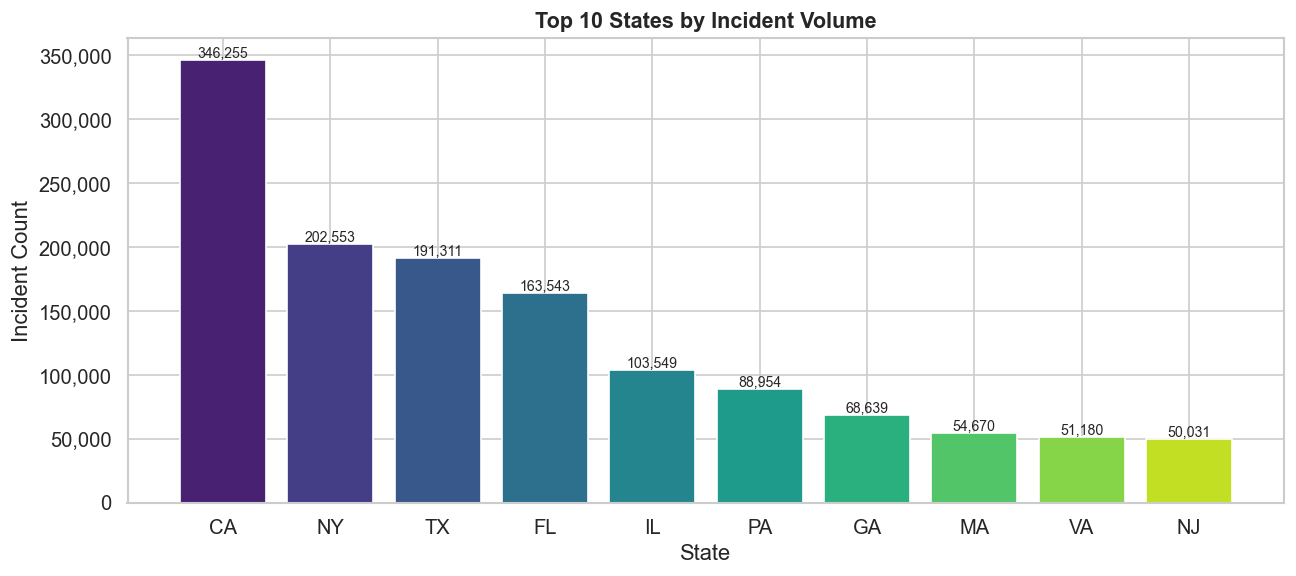

In [13]:
top10 = df['State'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(top10.index, top10.values, color=sns.color_palette('viridis', 10), edgecolor='white')
for bar, cnt in zip(bars, top10.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{cnt:,}', ha='center', fontsize=8.5)
ax.set_title('Top 10 States by Incident Volume', fontsize=13, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Incident Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### 5.13 Donut Chart — Congestion Speed Composition

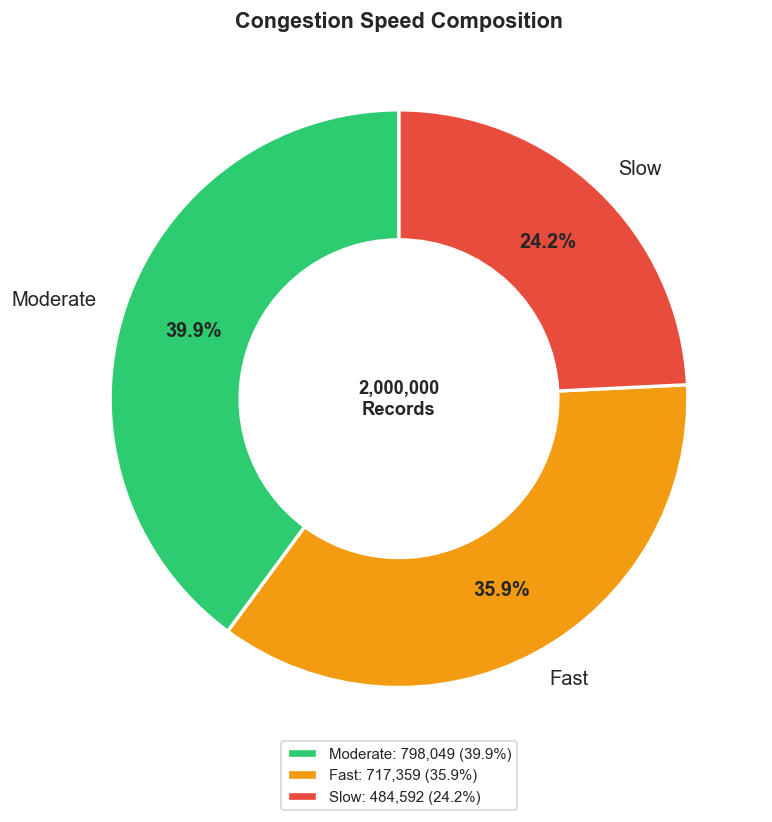

In [12]:
cs_counts = df['Congestion_Speed'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    cs_counts.values,
    labels=cs_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    pctdistance=0.75
)
for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

# Centre label
ax.text(0, 0, '2,000,000\nRecords', ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title('Congestion Speed Composition', fontsize=13, fontweight='bold')

# Legend with counts
legend_labels = [f'{k}: {v:,} ({v/len(df)*100:.1f}%)' for k, v in cs_counts.items()]
ax.legend(wedges, legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.08), fontsize=9)
plt.tight_layout()
plt.show()

## 8. Findings and Interpretations

| ID | Finding |
|----|---------|
| **F1** | **Severity Imbalance:** Severity 1 accounts for 46.7% of all incidents. Any classifier must address this via oversampling, undersampling, or class-weight adjustment. |
| **F2** | **Traffic Level as Delay Amplifier:** High traffic yields mean free-flow delay of 6.99 min — ~3.9× higher than Low-traffic conditions. |
| **F3** | **Snow Most Disruptive Weather:** Highest mean typical-traffic delay (2.92 min) and most High-traffic incidents (239,483). |
| **F4** | **Delay–Severity Moderate Correlation:** Pearson r ≈ 0.43–0.44; meaningful but not sufficient in isolation. |
| **F5** | **Geographic Concentration:** Top 5 states (CA, NY, TX, FL, IL) account for >50% of incidents. |
| **F6** | **Visibility Not Linearly Associated with Severity:** r ≈ −0.0001 due to extreme distributional skew; non-linear transforms needed. |
| **F7** | **Congestion Speed Reflects Severity Gradient:** Slow congestion mean delay (3.73 min) is 59% higher than Fast (2.35 min). |

## 9. Challenges

| ID | Challenge |
|----|----------|
| **C1** | **Extreme Class Imbalance (Severity 4):** Only 9 records — standard accuracy metrics misleading; consider merging with Severity 3. |
| **C2** | **Extreme Skewness in Delay Variables:** Kurtosis >100; violates normality assumptions — use non-parametric tests or log-transform. |
| **C3** | **Anomalous Visibility Distribution:** Skewness = 1,414; kurtosis ≈ 2,000,000; likely sensor error. Cannot use raw form for inference. |
| **C4** | **Scalability Constraints on Visualisation:** Scatter/pair plots require stratified sampling for 2M records. |
| **C5** | **High-Cardinality Categorical Features:** City (14,535) and County (1,940) unique values — need geographic clustering or embeddings. |
| **C6** | **Absence of Temporal Information:** No timestamp column — precludes time-series or seasonality analysis. |

## 10. Final Conclusion

This EDA of 2,000,000 US traffic incident records confirms that **traffic severity and induced delay are positively correlated**, with **high traffic level** and **snow weather events** emerging as the dominant amplifiers of disruption. The geographical concentration of incidents in California, New York, and Texas underscores the unequal spatial distribution of traffic risk.

Key data quality issues — anomalous visibility, extreme class imbalance at Severity 4, and heavy right-skew in delay/distance variables — must be addressed before predictive modelling. Future work should incorporate **temporal features**, **geospatial clustering**, and **non-linear models** to fully exploit this dataset's informational depth.

In [11]:
sns.pairplot(df)

Error in callback <function flush_figures at 0x000002C3394925C0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 